
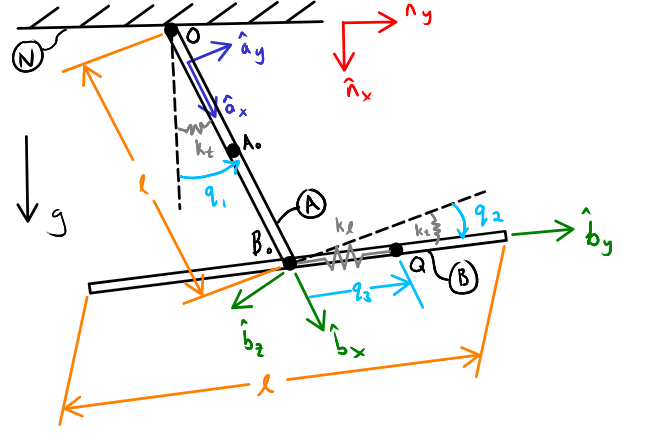

In [18]:
import sympy as sp
import sympy.physics.mechanics as me
me.init_vprinting()


In [19]:
# Variables

N, A, B = sp.symbols('N A B', cls=me.ReferenceFrame)
O, Ao, Bo, Q = sp.symbols('O, Ao, Bo, Q', cls=me.Point)
q1, q2, q3 = me.dynamicsymbols('q1:4')
u1, u2, u3 = me.dynamicsymbols('u1:4')
T1, T2 = me.dynamicsymbols('T1:3')
F = me.dynamicsymbols('F')
g, l, m, kt, kl = sp.symbols('g l m k_{t} k_{l}')
t = me.dynamicsymbols._t

# Frame setting

A.orient_axis(N, q1, N.z)
B.orient_axis(A, q2, A.x)

# Home setting

Ao.set_pos(O, l/2*A.x)
Bo.set_pos(Ao, l/2*B.x)
Q.set_pos(Bo, q3*B.y)

A.set_ang_vel(N, u1*N.z)
B.set_ang_vel(A, u2*A.x)

O.set_vel(N, 0)
Ao.set_vel(A, 0)
Bo.set_vel(B,0)
Q.set_vel(B, u3*B.y)

Ao.set_vel(N, Ao.v2pt_theory(O, N, A))
Bo.set_vel(N, Bo.v2pt_theory(Ao, N, B))
Q.set_vel(N, Q.v1pt_theory(Bo, N, B))


In [20]:
Ao.acc(N), Bo.acc(N), A.ang_acc_in(N), B.ang_acc_in(N)

In [21]:
Q.acc(N)

In [22]:
# Partial velocities

partial_vels = me.partial_velocity([Ao.vel(N), Bo.vel(N), Q.vel(N), A.ang_vel_in(N), B.ang_vel_in(N)],
                                   [u1, u2, u3],
                                   N)

partial_vels

In [23]:
Ao.vel(N)

In [24]:
vAo_u1 = partial_vels[0][0]
vBo_u1 = partial_vels[1][0]
vQ_u1 = partial_vels[2][0]
wA_u1 = partial_vels[3][0]
wB_u1 = partial_vels[4][0]

vAo_u2 = partial_vels[0][1]
vBo_u2 = partial_vels[1][1]
vQ_u2 = partial_vels[2][1]
wA_u2 = partial_vels[3][1]
wB_u2 = partial_vels[4][1]

vAo_u3 = partial_vels[0][2]
vBo_u3 = partial_vels[1][2]
vQ_u3 = partial_vels[2][2]
wA_u3 = partial_vels[3][2]
wB_u3 = partial_vels[4][2]



In [25]:
# resultant forces on the bodies
R_Ao = m*g*N.x
R_Bo = m*g*N.x + kl*q3*B.y
R_Q = m/4*g*N.x - kl*q3*B.y

# torque on the bodies
T_A = -kt*q1*N.z + kt*q2*A.x
T_B = -kt*q2*A.x


In [26]:
# Generalised Active forces

F_1 = vAo_u1.dot(R_Ao) + vBo_u1.dot(R_Bo) + vQ_u1.dot(R_Q) + wA_u1.dot(T_A) + wB_u1.dot(T_B)
F_2 = vAo_u2.dot(R_Ao) + vBo_u2.dot(R_Bo) + vQ_u2.dot(R_Q) + wA_u2.dot(T_A) + wB_u2.dot(T_B)
F_3 = vAo_u3.dot(R_Ao) + vBo_u3.dot(R_Bo) + vQ_u3.dot(R_Q) + wA_u3.dot(T_A) + wB_u3.dot(T_B)

Fr = sp.Matrix([F_1, F_2, F_3])
Fr.simplify()
Fr

⎡  7⋅g⋅l⋅m⋅sin(q₁)   g⋅m⋅q₃⋅cos(q₁)⋅cos(q₂)           ⎤
⎢- ─────────────── - ────────────────────── - k_{t}⋅q₁⎥
⎢         4                    4                      ⎥
⎢                                                     ⎥
⎢          g⋅m⋅q₃⋅sin(q₁)⋅sin(q₂)                     ⎥
⎢          ────────────────────── - k_{t}⋅q₂          ⎥
⎢                    4                                ⎥
⎢                                                     ⎥
⎢            g⋅m⋅sin(q₁)⋅cos(q₂)                      ⎥
⎢          - ─────────────────── - k_{l}⋅q₃           ⎥
⎣                     4                               ⎦

In [27]:
I = m*l**2/12
I_A_Ao = I*me.outer(A.y, A.y) + I*me.outer(A.z, A.z)
I_B_Bo = I*me.outer(B.x, B.x) + I*me.outer(B.z, B.z)

In [28]:
qdot_replace = {
    q1.diff(t) : u1,
    q2.diff(t) : u2,
    q3.diff(t) : u3,
}

Q.set_acc(N, Q.acc(N).xreplace(qdot_replace))
Q.acc(N)

In [29]:
Rs_Ao = -m*Ao.acc(N)
Rs_Bo = -m*Bo.acc(N)
Rs_Q = -m/4*Q.acc(N)

Ts_A = -((A.ang_acc_in(N)).dot(I_A_Ao) + me.cross(A.ang_vel_in(N),I_A_Ao.dot(A.ang_vel_in(N))))
Ts_B = -((B.ang_acc_in(N)).dot(I_B_Bo) + me.cross(B.ang_vel_in(N),I_B_Bo.dot(B.ang_vel_in(N))))


In [30]:
# Generalised inertia forces

Fs_1 = vAo_u1.dot(Rs_Ao) + vBo_u1.dot(Rs_Bo) + vQ_u1.dot(Rs_Q) + wA_u1.dot(Ts_A) + wB_u1.dot(Ts_B)
Fs_2 = vAo_u2.dot(Rs_Ao) + vBo_u2.dot(Rs_Bo) + vQ_u2.dot(Rs_Q) + wA_u2.dot(Ts_A) + wB_u2.dot(Ts_B)
Fs_3 = vAo_u3.dot(Rs_Ao) + vBo_u3.dot(Rs_Bo) + vQ_u3.dot(Rs_Q) + wA_u3.dot(Ts_A) + wB_u3.dot(Ts_B)

Frs = sp.Matrix([Fs_1, Fs_2, Fs_3])
Frs.simplify()
Frs

⎡  ⎛   2                    2                    2               2             ↪
⎢m⋅⎝2⋅l ⋅u₁⋅u₂⋅sin(2⋅q₂) - l ⋅cos(2⋅q₂)⋅u₁̇ - 39⋅l ⋅u₁̇ + 6⋅l⋅q₃⋅u₂ ⋅cos(q₂) + 6 ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                  ⎛   2   2   ↪
⎢                                                                  ⎜  l ⋅u₁ ⋅s ↪
⎢                                                                m⋅⎜- ──────── ↪
⎢                                                                  ⎝         2 ↪
⎢                                                                ───────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                         

In [31]:
eq = Fr + Frs

In [32]:
me.find_dynamicsymbols(Fr) , me.find_dynamicsymbols(Frs) 

In [33]:
me.find_dynamicsymbols(eq)

In [34]:
sp.Eq(eq, sp.Matrix([T1, T2, F]))

⎡                                                          ⎛   2               ↪
⎢  7⋅g⋅l⋅m⋅sin(q₁)   g⋅m⋅q₃⋅cos(q₁)⋅cos(q₂)              m⋅⎝2⋅l ⋅u₁⋅u₂⋅sin(2⋅q ↪
⎢- ─────────────── - ────────────────────── - k_{t}⋅q₁ + ───────────────────── ↪
⎢         4                    4                                               ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                          g⋅m ↪
⎢                                                                          ─── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           